# GANs with Keras


## 1. What is a GAN?

A GAN, or Generative Adversarial Network, is a system made of two neural networks that compete with each other.

These two networks are:

- **Generator**: tries to create fake data that looks real
- **Discriminator**: tries to distinguish real data from fake data

The generator starts from random noise and transforms it into an image.

The discriminator receives either:

- a real image from the dataset
- or a fake image created by the generator

and outputs a probability-like score indicating whether the image looks real.

The training idea is adversarial:

- the generator improves by trying to fool the discriminator
- the discriminator improves by trying not to be fooled

That tension is the core engine of GAN training.


## 2. Why GANs matter

GANs matter because they introduced a powerful way to generate realistic synthetic data.

They have been used for:

- image generation
- face synthesis
- image-to-image translation
- super-resolution
- style transfer
- data augmentation
- artistic generation

GANs are conceptually elegant and practically unstable. If you do not understand the training game between generator and discriminator, then you will get lost fast when training becomes noisy, collapses, or behaves unpredictably.


## 4. Import the libraries

We import:

- `numpy` for numerical operations
- `matplotlib` for visualization
- `tensorflow` / `keras` for building and training the models

Keep the setup minimal so the GAN logic stays visible.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, Model, Sequential

## 5. Load the dataset

We use MNIST because it is:

- small
- fast to train on
- easy to visualize
- good enough to see whether the generator is learning digit-like structure

Each image is grayscale and has shape `28 x 28`.


In [2]:
(x_train, _), (_, _) = keras.datasets.mnist.load_data()

print("x_train shape:", x_train.shape)

x_train shape: (60000, 28, 28)


## 7. Preprocess the images

We normalize the pixel values and reshape the images.

For GAN training, it is common to scale images to `[-1, 1]` when the generator output uses `tanh`.

That pairing matters:

- generator output activation: `tanh`
- real image value range: `[-1, 1]`

If you mismatch those, training gets worse for no good reason.


In [3]:
x_train = x_train.astype("float32") / 127.5 - 1.0
x_train = np.expand_dims(x_train, axis=-1)

print("Processed x_train shape:", x_train.shape)
print("Pixel range:", x_train.min(), x_train.max())

Processed x_train shape: (60000, 28, 28, 1)
Pixel range: -1.0 1.0


## 8. Define the generator

The generator takes a random latent vector as input.

This latent vector is usually sampled from a normal distribution.

The generator then maps that random vector into an image.

For this notebook, the generator will:

- take a noise vector
- pass it through dense layers
- reshape the output into an image

The goal is not sophistication. The goal is to understand how random noise becomes structured output.


In [4]:
latent_dim = 100
batch_size = 128
epochs = 50

generator = Sequential([
    layers.Input(shape=(latent_dim,)),
    layers.Dense(256),
    layers.LeakyReLU(negative_slope=0.2),

    layers.Dense(512),
    layers.LeakyReLU(negative_slope=0.2),

    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.2),

    layers.Dense(28 * 28 * 1, activation="tanh"),
    layers.Reshape((28, 28, 1))
], name="generator")

generator.summary()

 Non-trainable params: 0 (0.00 B)

## 9. Define the discriminator

The discriminator takes an image as input and predicts whether it is real or fake.

Its job is binary classification:

- real image -> target 1
- fake image -> target 0

The discriminator must become good enough to provide useful feedback to the generator, but not so dominant that the generator gets no learning signal.

That balance is one of the hardest parts of GAN training.


In [6]:
discriminator = Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Flatten(),

    layers.Dense(512),
    layers.LeakyReLU(negative_slope=0.2),

    layers.Dense(256),
    layers.LeakyReLU(negative_slope=0.2),

    layers.Dense(1, activation="sigmoid")
], name="discriminator")

discriminator.summary()

 Non-trainable params: 0 (0.00 B)

## 10. Build the adversarial GAN model

The GAN model combines generator and discriminator.

But there is an important detail:

when training the full GAN model, we freeze the discriminator weights.

Why?

Because during generator training, we want to update only the generator so it learns how to fool the fixed discriminator.

So there are really three training views:

- train discriminator on real and fake images
- train generator through the combined GAN model
- alternate these updates over time


## 11. Compile the discriminator and GAN

We compile the discriminator separately because it has its own learning objective.

We also compile the combined GAN model, which is used to train the generator.

For a basic GAN, binary crossentropy is the standard starting loss because the discriminator is solving a real-vs-fake binary classification problem.


In [14]:
discriminator.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

discriminator.trainable = False

gan_input = keras.Input(shape=(latent_dim,))
generated_image = generator(gan_input)
gan_output = discriminator(generated_image)

gan = Model(gan_input, gan_output, name="gan")
gan.summary()
gan.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
    loss="binary_crossentropy"
)

 Non-trainable params: 533,505 (2.04 MB)

## 13. Define helper function to sample real images

For discriminator training, we need batches of real images from the dataset.

We randomly sample them from the training set.

This is straightforward, but it matters because GAN training is based on repeatedly comparing real batches with fake batches.


In [10]:
def get_real_samples(dataset, n):
    idx = np.random.randint(0, dataset.shape[0], n)
    real_images = dataset[idx]
    real_labels = np.ones((n, 1))
    return real_images, real_labels

## 14. Define helper function to generate fake images

To train the discriminator, we also need fake images produced by the generator.

So we sample random latent vectors, pass them through the generator, and obtain synthetic images.


In [11]:
def get_fake_samples(generator, latent_dim, n):
    noise = np.random.normal(0, 1, (n, latent_dim))
    fake_images = generator.predict(noise, verbose=0)
    fake_labels = np.zeros((n, 1))
    return fake_images, fake_labels

In [12]:
def generate_latent_points(latent_dim, n):
    return np.random.normal(0, 1, (n, latent_dim))

## 16. Train the GAN with a custom loop

This is the heart of the notebook.

Each iteration has two parts:

### Step 1: Train the discriminator
- get a batch of real images
- generate a batch of fake images
- train discriminator on both

### Step 2: Train the generator
- sample latent vectors
- pretend their labels are real
- train the combined GAN model so the generator learns to fool the discriminator

That alternating loop is the engine of GAN learning.

If you do not understand this loop, then you do not understand GANs yet.


In [15]:
d_losses = []
g_losses = []

batches_per_epoch = x_train.shape[0] // batch_size
half_batch = batch_size // 2

for epoch in range(epochs):
    d_loss_epoch = []
    g_loss_epoch = []

    for _ in range(batches_per_epoch):
        discriminator.trainable = True

        real_images, real_labels = get_real_samples(x_train, half_batch)
        fake_images, fake_labels = get_fake_samples(generator, latent_dim, half_batch)

        d_loss_real = discriminator.train_on_batch(real_images, real_labels)
        d_loss_fake = discriminator.train_on_batch(fake_images, fake_labels)

        d_loss = 0.5 * (d_loss_real[0] + d_loss_fake[0])

        discriminator.trainable = False

        noise = generate_latent_points(latent_dim, batch_size)
        misleading_labels = np.ones((batch_size, 1))

        g_loss = gan.train_on_batch(noise, misleading_labels)

        d_loss_epoch.append(d_loss)
        g_loss_epoch.append(g_loss)

    mean_d_loss = np.mean(d_loss_epoch)
    mean_g_loss = np.mean(g_loss_epoch)

    d_losses.append(mean_d_loss)
    g_losses.append(mean_g_loss)

    print(f"Epoch {epoch + 1}/{epochs} - D loss: {mean_d_loss:.4f} - G loss: {mean_g_loss:.4f}")

Epoch 50/50 - D loss: 0.6428 - G loss: 0.9644


## 17. Track generator and discriminator losses

GAN training is not like normal supervised learning.

Losses may oscillate, spike, or move in unintuitive ways.

That means you should not judge progress only by the loss curves. You must also inspect generated images regularly.


In [16]:
noise = generate_latent_points(latent_dim, 16)
generated_images = generator.predict(noise, verbose=0)

In [17]:
generated_images = (generated_images + 1.0) / 2.0
generated_images = np.clip(generated_images, 0.0, 1.0)

## 18. Visualize generated samples

Now we check whether the generator is producing anything meaningful.

At first, the outputs may look like garbage.

Over time, if training works, digit-like structure should appear.


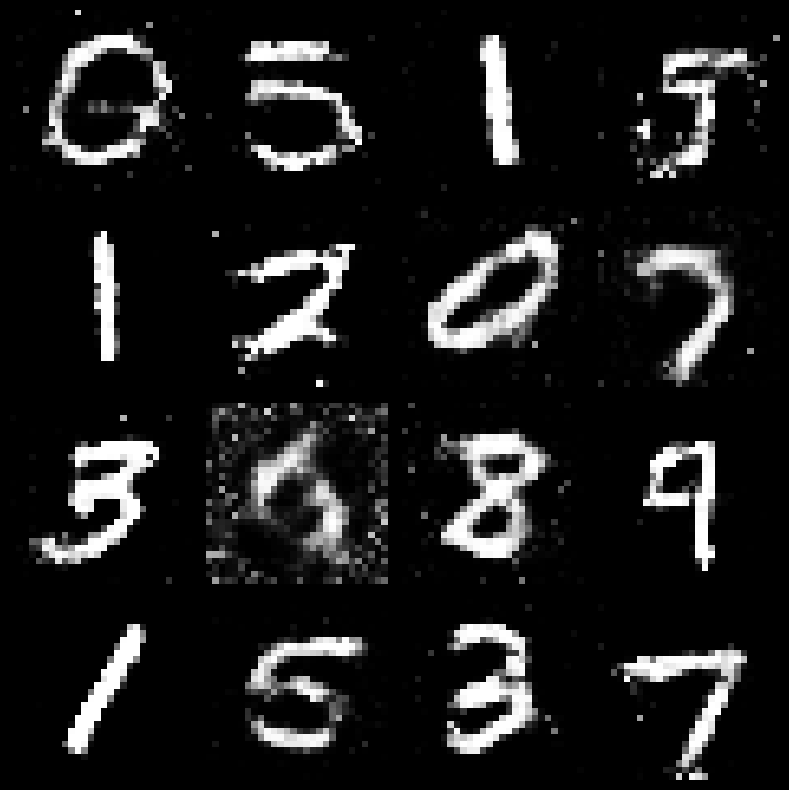

In [18]:
plt.figure(figsize=(8, 8))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(generated_images[i, :, :, 0], cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 19. Generate a fresh batch of images after training

Once training finishes, we generate a fresh set of samples using random latent vectors.

This is the real test of whether the generator learned any useful mapping from noise to image structure.


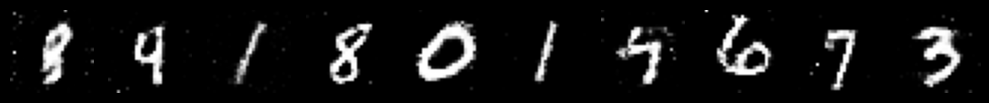

In [19]:
noise = generate_latent_points(latent_dim, 10)
fresh_images = generator.predict(noise, verbose=0)
fresh_images = (fresh_images + 1.0) / 2.0
fresh_images = np.clip(fresh_images, 0.0, 1.0)

plt.figure(figsize=(10, 2))

for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(fresh_images[i, :, :, 0], cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()